In [3]:
!pip install stim
!pip install pymatching
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 4.4 MB/s eta 0:00:00


In [4]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
import torch

In [5]:
# If CUDA is available, show more details
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("PyTorch is using CPU only")

CUDA version: 12.6
Number of GPUs: 1
GPU name: Tesla T4
Current device: 0


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
def surface_code_circuit(p, d): # physical error rate, distance
  return stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=d,
    distance=d,
    after_clifford_depolarization=p,
    after_reset_flip_probability=p,
    before_measure_flip_probability=p,
    before_round_data_depolarization=p)

def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
  # Sample the circuit.
  sampler = circuit.compile_detector_sampler()
  detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

  # Configure a decoder using the circuit.
  detector_error_model = circuit.detector_error_model(decompose_errors=True)
  matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

  # Run the decoder.
  predictions = matcher.decode_batch(detection_events)

  # basically compare predictions with observable_flips (what we should have measured)

  # Count the mistakes.
  num_errors = 0
  for shot in range(num_shots):
    actual_for_shot = observable_flips[shot]
    predicted_for_shot = predictions[shot]
    if not np.array_equal(actual_for_shot, predicted_for_shot):
        num_errors += 1
  return num_errors

def ler_mwpm(p, d): # logical error rate, minimum weight perfect matching
  num_shots = 100000
  circuit = surface_code_circuit(p, d)
  num_errors = count_logical_errors(circuit, num_shots)

  return num_errors / num_shots

def plot_mwpm():
  num_shots = 100000
  for d in [3, 5, 7]:
    xs = []
    ys = []
    yerrs = []
    for noise in np.linspace(0.001, 0.008, 8):
      ler = ler_mwpm(noise, d)
      xs.append(noise)
      ys.append(ler)
      yerrs.append(np.sqrt(ler * (1 - ler) / num_shots))
    plt.errorbar(xs, ys, yerr=yerrs, fmt='o-', label="d=" + str(d), capsize=3)
  plt.loglog()
  plt.xlabel("physical error rate")
  plt.ylabel("logical error rate per shot")
  plt.legend()
  plt.show()


after_clifford: after every operation e.g. H gate, you will apply X, Y, Z with probability p/3 each <br/>
after_reset_flip: after you do a reset (you think you're resetted to 0 but reset to 1 with probability p) <br/>
before_measure_flip: you should measuring a 0 but with p you're measuring a 1 <br/>
before_round_data_depolarization: we apply the same general error - errors no operation (interaction with the environment - decohere) - idling error

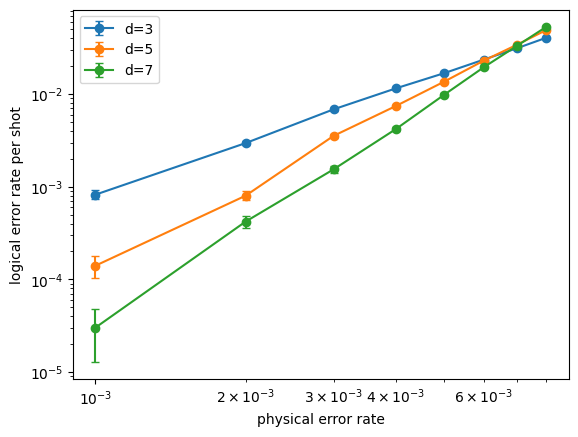

In [ ]:
# plot_mwpm()

In [ ]:
# do we need to train a model for each physical error rate or train at one physical error rate
# and then extrapolate at different physical error rates

# extrapolating distance: more difficult input shape
# evaluate the inference speed of the model
# data for distances

## Model Training

#### Definitions

In [8]:
from tqdm.auto import *
from torch import nn

def build_decoder(num_input):
  decoder = nn.Sequential(
    nn.Linear(num_input, 256),
    nn.SiLU(),
    nn.Linear(256, 512),
    nn.SiLU(),
    nn.Linear(512, 1024),
    nn.SiLU(),
    nn.Linear(1024, 1),
    nn.Sigmoid()
  ).to(device)
  loss_fn = nn.BCELoss() # inverse of accuracy

  # Create optimizer - if this fails with _utils error, run diagnostic cells above and reinstall PyTorch
  optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3) # tells you how to train
  # important here is lr, it cannot be too high, you are going to start missing out features, cannot be too slow, you are going to take forever
  return decoder, loss_fn, optimizer

def train_loop(measurements, flips, *, decoder, optimizer, loss_fn, train_size, bs=200):
  decoder.train()
  running_avg = 0
  with trange(train_size//bs) as pbar:
    for batch in pbar:
      X = measurements[batch*bs:(batch+1)*bs]
      y = flips[batch*bs:(batch+1)*bs][:,None]
      #pred = decoder(X.reshape((-1, 5*12)))
      pred = decoder(X)
      loss = loss_fn(pred, y)
      acc = torch.mean(((pred>0.5) == y).float())
      running_avg = acc * 0.01 + running_avg*0.99 if running_avg != 0 else acc
      # Backpropagation
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      if batch % 100 == 0:
        pbar.set_description(f'{running_avg:>4f} {loss:.4f}')

#### Training

goals:
1. train neural network for distance 5 and 7 and see the train size required to beat MWMP
2. see if models can extrapolate and have similar performance for different physical error rates

Seeing whether you can train higher distance models and the problem if you cannot

In [9]:
def evaluate_model(decoder, circuit, test_size=10000):
    """Evaluate decoder accuracy on fresh test data"""
    sampler = circuit.compile_detector_sampler()
    detections, flips = sampler.sample(shots=test_size, separate_observables=True)
    detections = torch.Tensor(detections.astype(int) * 2 - 1).to(device)
    flips = torch.Tensor(flips.astype(int).flatten()).to(device)

    decoder.eval()
    with torch.no_grad():
        pred = decoder(detections)
        accuracy = torch.mean(((pred > 0.5).flatten() == flips).float()).item()
    return accuracy

In [ ]:
import gc

p = 0.005  # physical error rate
results = {}

for d in [3, 5, 7]:
    print(f"\n{'='*50}")
    print(f"Distance {d}")
    print(f"{'='*50}")

    # Calculate MWPM accuracy threshold
    mwpm_accuracy = 1 - ler_mwpm(p, d)
    print(f"MWPM accuracy to beat: {mwpm_accuracy:.6f}")

    # Loop through training sizes: 10^2, 10^3, 10^4, ...
    train_size = 100  # Start at 10^2
    max_train_size = 10**20
    beat_mwpm = False

    while train_size <= max_train_size and not beat_mwpm:
        print(f"\nTrying train_size = {train_size:,}")

        # Generate training data
        circuit = surface_code_circuit(p, d)
        sampler = circuit.compile_detector_sampler()
        detections, flips = sampler.sample(shots=train_size, separate_observables=True)

        num_input = detections.shape[1]
        detections = torch.Tensor(detections.astype(int) * 2 - 1).to(device)
        flips = torch.Tensor(flips.astype(int).flatten()).to(device)

        # Build fresh model
        decoder, loss_fn, optimizer = build_decoder(num_input)

        # Train
        train_loop(detections, flips, decoder=decoder, optimizer=optimizer,
                   loss_fn=loss_fn, train_size=train_size, bs=min(256, train_size))

        # Evaluate
        nn_accuracy = evaluate_model(decoder, circuit)
        print(f"NN accuracy: {nn_accuracy:.6f} vs MWPM: {mwpm_accuracy:.6f}")

        if nn_accuracy > mwpm_accuracy:
            print(f"SUCCESS: NN beats MWPM at train_size = {train_size:,}")
            results[d] = train_size
            beat_mwpm = True
        else:
            train_size *= 10  # Increment by factor of 10

        # Clear memory after each iteration
        del detections, flips, decoder, loss_fn, optimizer, sampler
        gc.collect()
        torch.cuda.empty_cache()

    if not beat_mwpm:
        print(f"Did not beat MWPM within max train_size")
        results[d] = None

print(f"\n{'='*50}")
print("RESULTS SUMMARY")
print(f"{'='*50}")
for d, size in results.items():
    print(f"Distance {d}: {'train_size = ' + f'{size:,}' if size else 'Did not beat MWPM'}")



Distance 3
MWPM accuracy to beat: 0.982740

Trying train_size = 100


  0%|          | 0/1 [00:00<?, ?it/s]

NN accuracy: 0.890600 vs MWPM: 0.982740

Trying train_size = 1,000


  0%|          | 0/3 [00:00<?, ?it/s]

NN accuracy: 0.897700 vs MWPM: 0.982740

Trying train_size = 10,000


...

  0%|          | 0/390 [00:00<?, ?it/s]

NN accuracy: 0.774300 vs MWPM: 0.985540

Trying train_size = 1,000,000


  0%|          | 0/3906 [00:00<?, ?it/s]

NN accuracy: 0.924200 vs MWPM: 0.985540

Trying train_size = 10,000,000


  0%|          | 0/39062 [00:00<?, ?it/s]